In [8]:
%matplotlib inline
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager
import matplotlib.patheffects as path_effects
from getdist.mcsamples import MCSamplesFromCobaya
from getdist.mcsamples import loadMCSamples
import getdist.plots as gdplt
import yaml
from yaml.loader import SafeLoader
from scipy.stats import chi2
from scipy.special import erf
from scipy.optimize import fsolve
import json
# make plots pretty
plt.rc('font',**{'size':'22','family':'serif','serif':['CMU serif']})
plt.rc('mathtext', **{'fontset':'cm'})
plt.rc('text', usetex=True)
plt.rc('legend',**{'fontsize':'18'})
matplotlib.use(plt.rcParams["backend"])
matplotlib.rcParams['axes.linewidth'] = 3
matplotlib.rcParams['axes.labelsize'] = 30
matplotlib.rcParams['xtick.labelsize'] = 25 
matplotlib.rcParams['ytick.labelsize'] = 25
matplotlib.rcParams['legend.fontsize'] = 25
matplotlib.rcParams['xtick.major.size'] = 10
matplotlib.rcParams['ytick.major.size'] = 10
matplotlib.rcParams['xtick.minor.size'] = 5
matplotlib.rcParams['ytick.minor.size'] = 5
matplotlib.rcParams['xtick.major.width'] = 3
matplotlib.rcParams['ytick.major.width'] = 3
matplotlib.rcParams['xtick.minor.width'] = 1.5
matplotlib.rcParams['ytick.minor.width'] = 1.5
matplotlib.rcParams['axes.titlesize'] = 30
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath, amssymb}'

ppd_cmb      = json.load(open('ppd_lcdm_mnu=0.06_tau=0.06_cmb-p+cmb-l.json'))
ppd_high_tau = json.load(open('ppd_lcdm_mnu=0.06_tau=0.09_cmb-p+cmb-l+bao.json'))
ppd_w0wa     = json.load(open('ppd_w0wa_mnu=0.06_tau=0.06_cmb-p+cmb-l+bao.json'))
ppd_omk      = json.load(open('ppd_omk_mnu=0.06_tau=0.06_cmb-p+cmb-l+bao.json'))

z = ppd_cmb['mean_prediction']['z']
k = ppd_cmb['mean_prediction']['k [h/Mpc]']


# https://arxiv.org/pdf/2503.14738
z_desi = [0.295, 0.510, 0.706, 0.934, 1.321, 1.484, 2.330, 0.922, 0.955]
dv_over_rd_desi = np.array([[7.942, 0.075],
 [12.720, 0.099],
 [16.050, 0.110],
 [19.721, 0.091],
 [24.252, 0.174],
 [26.055, 0.398],
 [31.267, 0.256],
 [19.656, 0.105],
 [20.008, 0.183]])
dm_over_dh_desi = np.array([[-1, -1],
 [0.622, 0.017],
 [0.892, 0.021],
 [1.223, 0.019],
 [1.948, 0.045],
 [2.386, 0.136],
 [4.518, 0.097],
 [1.232, 0.021],
 [1.220, 0.033]])

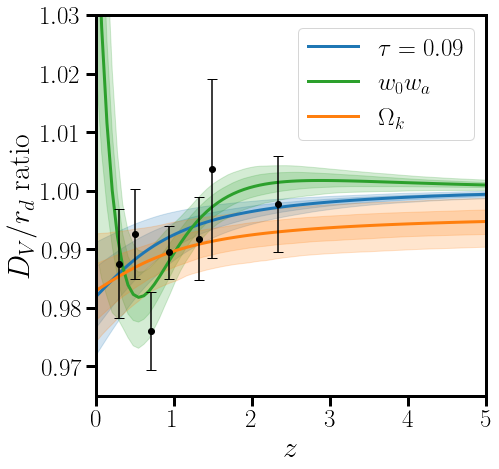

In [22]:
plt.figure(figsize=(7, 7))
fiducial = np.array(ppd_cmb['best_fit_prediction']['DV_div_rd'])
plt.plot(z, np.array(ppd_high_tau['mean_prediction']['DV_div_rd'])/fiducial,lw=3,c='C0', label=r'$\tau=0.09$')
plt.plot(z, np.array(ppd_w0wa['mean_prediction']['DV_div_rd'])/fiducial,lw=3,c='C2', label=r'$w_0w_a$')
plt.plot(z, np.array(ppd_omk['mean_prediction']['DV_div_rd'])/fiducial,lw=3,c='C1', label=r'$\Omega_k$')

plt.fill_between(z,np.array(ppd_high_tau['2sigma_low']['DV_div_rd'])/fiducial,np.array(ppd_high_tau['2sigma_high']['DV_div_rd'])/fiducial,color='C0',alpha=0.2)
plt.fill_between(z,np.array(ppd_high_tau['1sigma_low']['DV_div_rd'])/fiducial,np.array(ppd_high_tau['1sigma_high']['DV_div_rd'])/fiducial,color='C0',alpha=0.2)

plt.fill_between(z,np.array(ppd_w0wa['2sigma_low']['DV_div_rd'])/fiducial,np.array(ppd_w0wa['2sigma_high']['DV_div_rd'])/fiducial,color='C2',alpha=0.2)
plt.fill_between(z,np.array(ppd_w0wa['1sigma_low']['DV_div_rd'])/fiducial,np.array(ppd_w0wa['1sigma_high']['DV_div_rd'])/fiducial,color='C2',alpha=0.2)

plt.fill_between(z,np.array(ppd_omk['2sigma_low']['DV_div_rd'])/fiducial,np.array(ppd_omk['2sigma_high']['DV_div_rd'])/fiducial,color='C1',alpha=0.2)
plt.fill_between(z,np.array(ppd_omk['1sigma_low']['DV_div_rd'])/fiducial,np.array(ppd_omk['1sigma_high']['DV_div_rd'])/fiducial,color='C1',alpha=0.2)


fid_desi = np.interp(z_desi,z,fiducial)[:-2]
plt.errorbar(z_desi[:-2],dv_over_rd_desi[:-2,0]/fid_desi,yerr=dv_over_rd_desi[:-2,1]/fid_desi,capsize=5,color='k',ls='',marker='o')


#plt.axhline(y=1,c='k',lw=2)
plt.xlabel(r"$z$")
plt.ylabel(r"$D_V/r_d$ ratio")
plt.legend()
plt.xlim(0,5)
plt.ylim(0.965,1.03)
plt.savefig('../figures/dv_ratio.pdf',bbox_inches='tight')

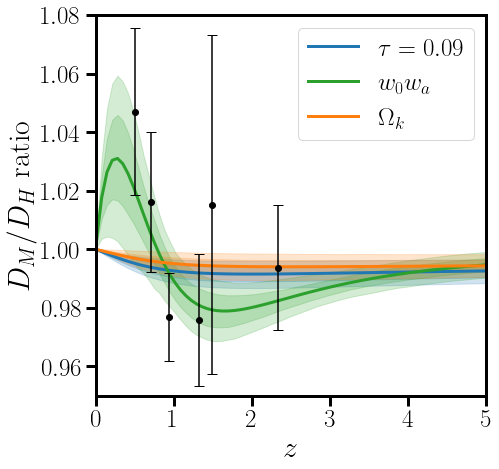

In [21]:
plt.figure(figsize=(7, 7))
fiducial = np.array(ppd_cmb['best_fit_prediction']['DM_div_DH'])
plt.plot(z, np.array(ppd_high_tau['mean_prediction']['DM_div_DH'])/fiducial,lw=3,c='C0', label=r'$\tau=0.09$')
#plt.plot(z, np.array(ppd_high_tau['best_fit_prediction']['DM_div_DH'])/fiducial,lw=3,c='C0', ls='--')
plt.plot(z, np.array(ppd_w0wa['mean_prediction']['DM_div_DH'])/fiducial,lw=3,c='C2', label=r'$w_0w_a$')
#plt.plot(z, np.array(ppd_w0wa['best_fit_prediction']['DM_div_DH'])/fiducial,lw=3,c='C2',ls='--')
plt.plot(z, np.array(ppd_omk['mean_prediction']['DM_div_DH'])/fiducial,lw=3,c='C1', label=r'$\Omega_k$')

plt.fill_between(z,np.array(ppd_high_tau['2sigma_low']['DM_div_DH'])/fiducial,np.array(ppd_high_tau['2sigma_high']['DM_div_DH'])/fiducial,color='C0',alpha=0.2)
plt.fill_between(z,np.array(ppd_high_tau['1sigma_low']['DM_div_DH'])/fiducial,np.array(ppd_high_tau['1sigma_high']['DM_div_DH'])/fiducial,color='C0',alpha=0.2)

plt.fill_between(z,np.array(ppd_w0wa['2sigma_low']['DM_div_DH'])/fiducial,np.array(ppd_w0wa['2sigma_high']['DM_div_DH'])/fiducial,color='C2',alpha=0.2)
plt.fill_between(z,np.array(ppd_w0wa['1sigma_low']['DM_div_DH'])/fiducial,np.array(ppd_w0wa['1sigma_high']['DM_div_DH'])/fiducial,color='C2',alpha=0.2)

plt.fill_between(z,np.array(ppd_omk['2sigma_low']['DM_div_DH'])/fiducial,np.array(ppd_omk['2sigma_high']['DM_div_DH'])/fiducial,color='C1',alpha=0.2)
plt.fill_between(z,np.array(ppd_omk['1sigma_low']['DM_div_DH'])/fiducial,np.array(ppd_omk['1sigma_high']['DM_div_DH'])/fiducial,color='C1',alpha=0.2)

fid_desi = np.interp(z_desi,z,fiducial)[1:-2]
plt.errorbar(z_desi[1:-2],dm_over_dh_desi[1:-2,0]/fid_desi,yerr=dm_over_dh_desi[1:-2,1]/fid_desi,capsize=5,color='k',ls='',marker='o')


#plt.axhline(y=1,c='k',lw=2)
plt.xlabel(r"$z$")
plt.ylabel(r"$D_M/D_H$ ratio")
plt.legend()
plt.xlim(0,5)
plt.ylim(0.95,1.08)
plt.savefig('../figures/dmdh_ratio.pdf',bbox_inches='tight')

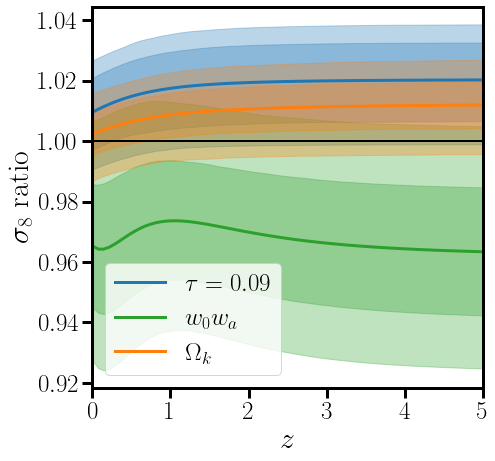

In [5]:
plt.figure(figsize=(7, 7))
fiducial = np.array(ppd_cmb['best_fit_prediction']['sigma8z'])
plt.plot(z, np.array(ppd_high_tau['mean_prediction']['sigma8z'])/fiducial,lw=3,c='C0', label=r'$\tau=0.09$')
plt.plot(z, np.array(ppd_w0wa['mean_prediction']['sigma8z'])/fiducial,lw=3,c='C2', label=r'$w_0w_a$')
plt.plot(z, np.array(ppd_omk['mean_prediction']['sigma8z'])/fiducial,lw=3,c='C1', label=r'$\Omega_k$')

plt.fill_between(z,np.array(ppd_high_tau['2sigma_low']['sigma8z'])/fiducial,np.array(ppd_high_tau['2sigma_high']['sigma8z'])/fiducial,color='C0',alpha=0.3)
plt.fill_between(z,np.array(ppd_high_tau['1sigma_low']['sigma8z'])/fiducial,np.array(ppd_high_tau['1sigma_high']['sigma8z'])/fiducial,color='C0',alpha=0.3)

plt.fill_between(z,np.array(ppd_w0wa['2sigma_low']['sigma8z'])/fiducial,np.array(ppd_w0wa['2sigma_high']['sigma8z'])/fiducial,color='C2',alpha=0.3)
plt.fill_between(z,np.array(ppd_w0wa['1sigma_low']['sigma8z'])/fiducial,np.array(ppd_w0wa['1sigma_high']['sigma8z'])/fiducial,color='C2',alpha=0.3)

plt.fill_between(z,np.array(ppd_omk['2sigma_low']['sigma8z'])/fiducial,np.array(ppd_omk['2sigma_high']['sigma8z'])/fiducial,color='C1',alpha=0.3)
plt.fill_between(z,np.array(ppd_omk['1sigma_low']['sigma8z'])/fiducial,np.array(ppd_omk['1sigma_high']['sigma8z'])/fiducial,color='C1',alpha=0.3)

plt.axhline(y=1,c='k',lw=2)
plt.xlabel(r"$z$")
plt.ylabel(r"$\sigma_8$ ratio")
plt.legend()
plt.xlim(0,5)
plt.savefig('../figures/sigma8_ratio.pdf',bbox_inches='tight')

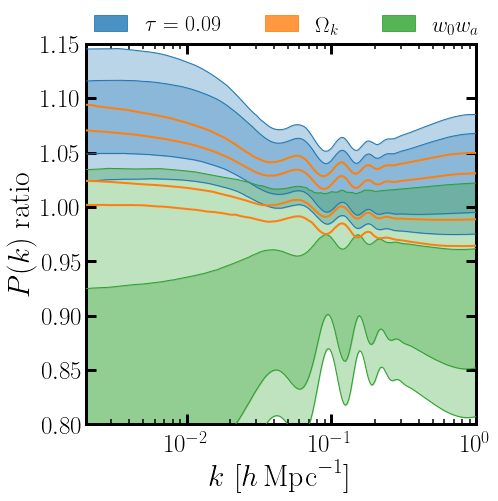

In [7]:
plt.figure(figsize=(7, 7))
def fill_between(x,y1,y2,c,alpha,lw,zorder=0):
    plt.fill_between(x,y1,y2,alpha=alpha,color=c,zorder=zorder)
    plt.plot(x,y1,c=c,lw=lw,zorder=10)
    plt.plot(x,y2,c=c,lw=lw,zorder=10)
fiducial = np.array(ppd_cmb['best_fit_prediction']['Pcb_nonlin [(Mpc/h)^3]'])[0,:]
#plt.semilogx(k, np.array(ppd_high_tau['mean_prediction']['Pcb_nonlin [(Mpc/h)^3]'])[0,:]/fiducial,lw=3,c='C0')
#plt.semilogx(k, np.array(ppd_omk['mean_prediction']['Pcb_nonlin [(Mpc/h)^3]'])[0,:]/fiducial,lw=3,c='C1')
#plt.semilogx(k, np.array(ppd_w0wa['mean_prediction']['Pcb_nonlin [(Mpc/h)^3]'])[0,:]/fiducial,lw=3,c='C2')

#plt.semilogx(k, np.array(ppd_high_tau['best_fit_prediction']['Pcb_nonlin [(Mpc/h)^3]'])[0,:]/fiducial,lw=3,c='C0',ls='-.')
#plt.semilogx(k, np.array(ppd_omk['best_fit_prediction']['Pcb_nonlin [(Mpc/h)^3]'])[0,:]/fiducial,lw=3,c='C1',ls='-.')
#plt.semilogx(k, np.array(ppd_w0wa['best_fit_prediction']['Pcb_nonlin [(Mpc/h)^3]'])[0,:]/fiducial,lw=3,c='C2',ls='-.')

fill_between(k,np.array(ppd_high_tau['2sigma_low']['Pcb_nonlin [(Mpc/h)^3]'])[0,:]/fiducial,np.array(ppd_high_tau['2sigma_high']['Pcb_nonlin [(Mpc/h)^3]'])[0,:]/fiducial,'C0',0.3,1)
fill_between(k,np.array(ppd_high_tau['1sigma_low']['Pcb_nonlin [(Mpc/h)^3]'])[0,:]/fiducial,np.array(ppd_high_tau['1sigma_high']['Pcb_nonlin [(Mpc/h)^3]'])[0,:]/fiducial,'C0',0.3,1)

fill_between(k,np.array(ppd_w0wa['2sigma_low']['Pcb_nonlin [(Mpc/h)^3]'])[0,:]/fiducial,np.array(ppd_w0wa['2sigma_high']['Pcb_nonlin [(Mpc/h)^3]'])[0,:]/fiducial,'C2',0.3,1)
fill_between(k,np.array(ppd_w0wa['1sigma_low']['Pcb_nonlin [(Mpc/h)^3]'])[0,:]/fiducial,np.array(ppd_w0wa['1sigma_high']['Pcb_nonlin [(Mpc/h)^3]'])[0,:]/fiducial,'C2',0.3,1)


fill_between(k,np.array(ppd_omk['2sigma_low']['Pcb_nonlin [(Mpc/h)^3]'])[0,:]/fiducial,np.array(ppd_omk['2sigma_high']['Pcb_nonlin [(Mpc/h)^3]'])[0,:]/fiducial,'C1',0.,2,zorder=2)
fill_between(k,np.array(ppd_omk['1sigma_low']['Pcb_nonlin [(Mpc/h)^3]'])[0,:]/fiducial,np.array(ppd_omk['1sigma_high']['Pcb_nonlin [(Mpc/h)^3]'])[0,:]/fiducial,'C1',0.,2,zorder=2)


plt.fill_between([],[],[],color='C0',alpha=0.8,label=r'$\tau=0.09$')
plt.fill_between([],[],[],color='C1',alpha=0.8,label=r'$\Omega_k$')
plt.fill_between([],[],[],color='C2',alpha=0.8,label=r'$w_0w_a$')


#plt.axhline(y=1,c='k',lw=2)
plt.xlabel(r"$k\,\,[h\,\text{Mpc}^{-1}]$")
plt.ylabel(r"$P(k)$ ratio")
plt.xlim(2e-3,1)
plt.ylim(0.8,1.15)
plt.xscale('log')
plt.legend(framealpha=0,loc=(0,1),ncol=3,handlelength=1.5,fontsize=22)
plt.tick_params(direction='in', which='both', top=True, right=True)
plt.tick_params(axis='x', which='both', pad=10)
plt.savefig('../figures/pk_ratio.pdf',bbox_inches='tight')

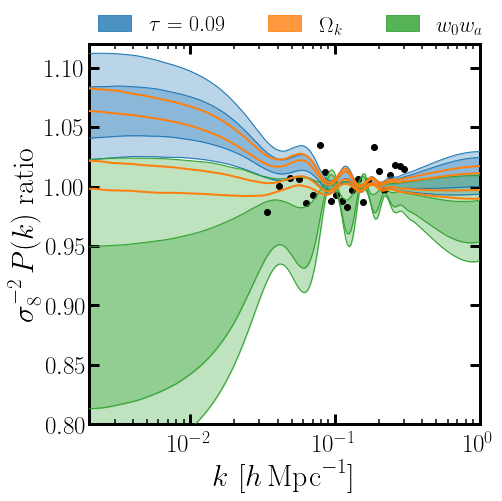

In [18]:
plt.figure(figsize=(7, 7))
def fill_between(x,y1,y2,c,alpha,lw,zorder=0):
    plt.fill_between(x,y1,y2,alpha=alpha,color=c,zorder=zorder)
    plt.plot(x,y1,c=c,lw=lw,zorder=10)
    plt.plot(x,y2,c=c,lw=lw,zorder=10)
fiducial = np.array(ppd_cmb['best_fit_prediction']['Pcb_nonlin_norm [(Mpc/h)^3]'])[0,:]
#plt.semilogx(k, np.array(ppd_high_tau['mean_prediction']['Pcb_nonlin_norm [(Mpc/h)^3]'])[0,:]/fiducial,lw=3,c='C0')
#plt.semilogx(k, np.array(ppd_omk['mean_prediction']['Pcb_nonlin_norm [(Mpc/h)^3]'])[0,:]/fiducial,lw=3,c='C1')
#plt.semilogx(k, np.array(ppd_w0wa['mean_prediction']['Pcb_nonlin_norm [(Mpc/h)^3]'])[0,:]/fiducial,lw=3,c='C2')

#plt.semilogx(k, np.array(ppd_high_tau['best_fit_prediction']['Pcb_nonlin_norm [(Mpc/h)^3]'])[0,:]/fiducial,lw=3,c='C0',ls='-.')
#plt.semilogx(k, np.array(ppd_omk['best_fit_prediction']['Pcb_nonlin_norm [(Mpc/h)^3]'])[0,:]/fiducial,lw=3,c='C1',ls='-.')
#plt.semilogx(k, np.array(ppd_w0wa['best_fit_prediction']['Pcb_nonlin_norm [(Mpc/h)^3]'])[0,:]/fiducial,lw=3,c='C2',ls='-.')

fill_between(k,np.array(ppd_high_tau['2sigma_low']['Pcb_nonlin_norm [(Mpc/h)^3]'])[0,:]/fiducial,np.array(ppd_high_tau['2sigma_high']['Pcb_nonlin_norm [(Mpc/h)^3]'])[0,:]/fiducial,'C0',0.3,1)
fill_between(k,np.array(ppd_high_tau['1sigma_low']['Pcb_nonlin_norm [(Mpc/h)^3]'])[0,:]/fiducial,np.array(ppd_high_tau['1sigma_high']['Pcb_nonlin_norm [(Mpc/h)^3]'])[0,:]/fiducial,'C0',0.3,1)

fill_between(k,np.array(ppd_w0wa['2sigma_low']['Pcb_nonlin_norm [(Mpc/h)^3]'])[0,:]/fiducial,np.array(ppd_w0wa['2sigma_high']['Pcb_nonlin_norm [(Mpc/h)^3]'])[0,:]/fiducial,'C2',0.3,1)
fill_between(k,np.array(ppd_w0wa['1sigma_low']['Pcb_nonlin_norm [(Mpc/h)^3]'])[0,:]/fiducial,np.array(ppd_w0wa['1sigma_high']['Pcb_nonlin_norm [(Mpc/h)^3]'])[0,:]/fiducial,'C2',0.3,1)


fill_between(k,np.array(ppd_omk['2sigma_low']['Pcb_nonlin_norm [(Mpc/h)^3]'])[0,:]/fiducial,np.array(ppd_omk['2sigma_high']['Pcb_nonlin_norm [(Mpc/h)^3]'])[0,:]/fiducial,'C1',0.,2,zorder=2)
fill_between(k,np.array(ppd_omk['1sigma_low']['Pcb_nonlin_norm [(Mpc/h)^3]'])[0,:]/fiducial,np.array(ppd_omk['1sigma_high']['Pcb_nonlin_norm [(Mpc/h)^3]'])[0,:]/fiducial,'C1',0.,2,zorder=2)


plt.fill_between([],[],[],color='C0',alpha=0.8,label=r'$\tau=0.09$')
plt.fill_between([],[],[],color='C1',alpha=0.8,label=r'$\Omega_k$')
plt.fill_between([],[],[],color='C2',alpha=0.8,label=r'$w_0w_a$')


desi=np.array([[0.03373318594236065, 0.9783388195366245],
[0.04114335092964479, 1.000693804393551],
[0.04849500112892027, 1.0074355444466638],
[0.055963457025912496, 1.0067265729165258],
[0.0633328811731225, 0.9864306018984794],
[0.07074548433889855, 0.9929481922940759],
[0.07825764565273681, 1.034584206270641],
[0.08577692310476612, 1.0119170290988315],
[0.0936784466736917, 0.9876955093621252],
[0.10212874902161986, 0.9928835540744658],
[0.1112290077733855, 0.9879957563184631],
[0.12105342347739989, 0.98239474070719],
[0.13174559073163875, 0.9974401946106161],
[0.1433821545779654, 1.0066680042420588],
[0.1560465298098394, 0.9870526822885268],
[0.16982949891753976, 1.0049523213769698],
[0.18482986284751093, 1.0331265416411297],
[0.20115514924069228, 1.0132599295160345],
[0.21892238322672186, 0.9970157832424662],
[0.23825892629932396, 1.009837259778404],
[0.25930338928622454, 1.0182758065923918],
[0.2822066259580642, 1.0175747812308624],
[0.29923731818080207, 1.014901486638356]])

plt.scatter(desi[:,0],desi[:,1],color='k',marker='o')


#plt.axhline(y=1,c='k',lw=2)
plt.xlabel(r"$k\,\,[h\,\text{Mpc}^{-1}]$")
plt.ylabel(r"$\sigma_8^{-2}\,P(k)$ ratio")
plt.xlim(2e-3,1)
plt.ylim(0.8,1.12)
plt.xscale('log')
plt.legend(framealpha=0,loc=(0,1),ncol=3,handlelength=1.5,fontsize=22)
plt.tick_params(direction='in', which='both', top=True, right=True)
plt.tick_params(axis='x', which='both', pad=10)
plt.savefig('../figures/pk_norm_ratio.pdf',bbox_inches='tight')